In [1]:
# --- ANALISE EXPLORATORIA  ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual dos gráficos para um padrão executivo
sns.set_theme(style="whitegrid")

# 1. Carregando os dados PROCESSADOS (limpos e padronizados na Fase 2)
caminho_arquivo = '../dados/processed/leads_insightos_limpo.csv'
df = pd.read_csv(caminho_arquivo)

# 2. Gerando as Estatísticas Descritivas para entender a distribuição dos dados
print("--- ESTATÍSTICAS DESCRITIVAS ---")
display(df.describe().round(2))

# 3. Calculando a proporção da nossa Variável Alvo (converteu)
# Isso define o nosso "Baseline" (linha de base) de conversão atual das campanhas
print("\n--- DISTRIBUIÇÃO DA VARIÁVEL ALVO (CONVERTEU) ---")
taxa_conversao = df['converteu'].value_counts(normalize=True) * 100
display(taxa_conversao.round(2).astype(str) + '%')

--- ESTATÍSTICAS DESCRITIVAS ---


,dispositivo,metodo_tracking,paginas_vistas,tempo_sessao_segundos,scroll_depth_max,baixou_material_rico,cargo,tamanho_empresa,tipo_email,converteu,...,origem_canal_LinkedIn Ads,origem_canal_Meta Ads,origem_canal_Organic Search,origem_canal_Referral,campanha_tipo_Lookalike,campanha_tipo_Nenhuma,campanha_tipo_PMax,campanha_tipo_Retargeting,campanha_tipo_Search,campanha_tipo_Sem Rastreio
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00,...,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,0.30,0.39,0.50,0.31,0.50,0.2,3.03,2.50,0.40,0.42,...,0.09,0.24,0.13,0.04,0.13,0.13,0.14,0.14,0.14,0.17
std,0.46,0.49,0.31,0.23,0.37,0.4,1.24,1.13,0.49,0.49,...,0.28,0.43,0.33,0.20,0.34,0.34,0.35,0.34,0.35,0.38
min,0.00,0.00,0.00,0.00,0.00,0.0,1.00,1.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.23,0.12,0.33,0.0,2.00,1.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.46,0.25,0.67,0.0,3.00,2.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,1.00,0.77,0.46,0.67,0.0,4.00,4.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.0,5.00,4.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00



--- DISTRIBUIÇÃO DA VARIÁVEL ALVO (CONVERTEU) ---


converteu
0    58.36%
1    41.64%
Name: proportion, dtype: str

### 📝 Insight 1: Estatísticas Descritivas e Baseline de Negócio
* **Visão Geral:** Nossa base contém 5.000 leads processados. Observando o `describe()`, confirmamos que as variáveis numéricas (como tempo de sessão e páginas vistas) estão corretamente normalizadas (min = 0.00, max = 1.00), garantindo que o algoritmo não sofra viés de escala.
* **Baseline de Conversão:** Analisando a variável alvo (`converteu`), notamos que o cenário reflete a realidade do Marketing de Performance. A maioria dos leads, **58.36%**, não converte, enquanto **41.64%** viram clientes. 
* **Próximo Passo:** Como temos uma boa distribuição (mas ainda com predominância de não-compradores), nosso desafio analítico é encontrar quais características (origem, cargo, comportamento) isolam essa fatia de 41.64% que realmente converte.


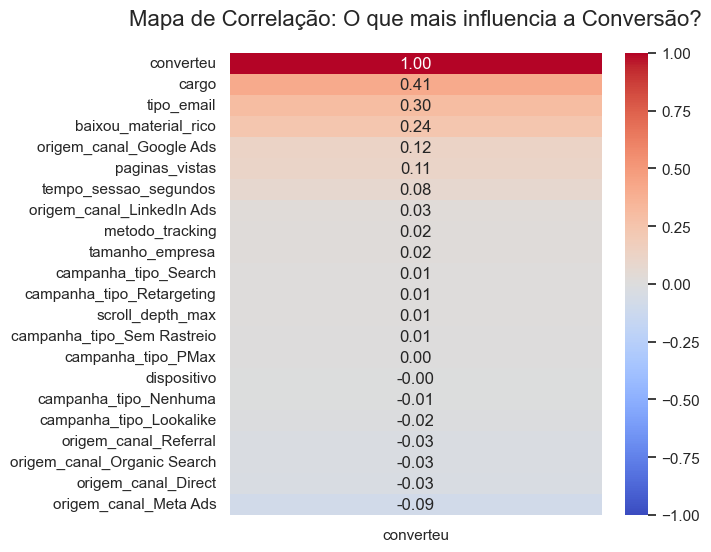

In [4]:
# --- EDA: MATRIZ DE CORRELAÇÃO ---

# Ajustando o tamanho do gráfico
plt.figure(figsize=(6, 6))

# Calculando a correlação de todas as variáveis APENAS com a variável alvo ('converteu')
# O sort_values organiza da maior correlação positiva para a maior negativa
correlacoes = df.corr()[['converteu']].sort_values(by='converteu', ascending=False)

# Criando um Heatmap (Mapa de Calor) para visualização
sns.heatmap(correlacoes, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

# Adicionando título
plt.title('Mapa de Correlação: O que mais influencia a Conversão?', fontsize=16, pad=20)
plt.show()

### 📝 Insight 2: Análise do Mapa de Correlação - Inteligência de Negócio

Ao analisarmos o comportamento das variáveis em relação à conversão final (`converteu`), podemos quebrar os dados em quatro grandes descobertas estratégicas:

**1. O Perfil do Decisor**
A matemática comprova que o produto não é de compra por impulso. Os maiores impulsionadores de venda são características do usuário, e não a mídia que ele consumiu.
* O **cargo** ($0.41$) é o fator mais determinante para a conversão. Quanto maior a senioridade, maior a chance de fechamento. 
* O **tipo_email** ($0.30$) valida a intenção. E-mails corporativos indicam que o usuário está pesquisando uma solução para a empresa, e não apenas navegando por curiosidade pessoal.
* A ação de **baixou_material_rico** ($0.24$) mostra que leads educados pelo Marketing têm taxas de conversão substancialmente maiores.

**2. Volume vs. Qualidade**
Métricas clássicas de vaidade do Google Analytics não garantem vendas neste cenário.
* **paginas_vistas** ($0.11$) e **tempo_sessao_segundos** ($0.08$) têm correlações fracas. Um usuário passar muito tempo no site não significa intenção de compra; pode ser apenas um estudante pesquisando para um trabalho da faculdade. A equipe de vendas não deve priorizar leads apenas por "tempo de navegação" se o cargo for baixo.

**3. Onde alocar o orçamento**
O mapa nos dá um direcionamento claro de realocação de verba de Tráfego Pago:
* **Google Ads** ($0.12$) é o canal de aquisição com a melhor tração positiva, indicando que leads que chegam por busca ativa têm maior intenção.
* **Meta Ads** ($-0.09$) é o nosso maior detrator. Neste exato momento, o dinheiro investido no Facebook/Instagram está trazendo um volume de leads desqualificados que sujam o funil do CRM e diminuem a taxa média de conversão. 

**4. O Ruído das Campanhas e Rastreamento**
* Os tipos de campanha isolados (`PMax` $0.00$, `Search` $0.01$, `Retargeting` $0.01$) não mostraram força matemática sozinhos. Isso indica que a mensagem/anúncio importa menos do que "quem" está clicando.
* A variável **metodo_tracking** ($0.02$) mostra uma leve vantagem positiva, indicando que há algo oculto sobre a qualidade dos dados que chegam via Server-Side que precisamos explorar.

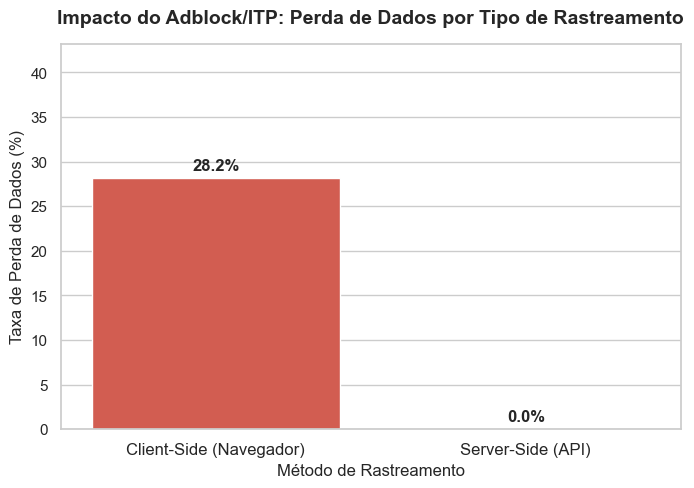

In [6]:
# ---  EDA: IMPACTO DO SERVER-SIDE VS CLIENT-SIDE ---

# Calculando a porcentagem de leads que perderam o rastreamento (Sem Rastreio == 1)
# agrupado pelo método de tracking (0 = Client-side, 1 = Server-side)
perda_rastreio = df.groupby('metodo_tracking')['campanha_tipo_Sem Rastreio'].mean() * 100

# Configurando e criando o gráfico de barras
plt.figure(figsize=(8, 5))
cores = ['#e74c3c', '#2ecc71'] # Vermelho (alerta) e Verde (sucesso)

# Criando o gráfico com a sintaxe atualizada do Seaborn para evitar warnings!
ax = sns.barplot(x=perda_rastreio.index, y=perda_rastreio.values, hue=perda_rastreio.index, palette=cores, legend=False)

# Ajustando os rótulos do eixo X
ax.set_xticks([0, 1])
ax.set_xticklabels(['Client-Side (Navegador)', 'Server-Side (API)'], fontsize=12)

# Títulos e labels
plt.title('Impacto do Adblock/ITP: Perda de Dados por Tipo de Rastreamento', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Taxa de Perda de Dados (%)', fontsize=12)
plt.xlabel('Método de Rastreamento', fontsize=12)

# Adicionando as porcentagens em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

# Dando um respiro no limite do eixo Y
plt.ylim(0, max(perda_rastreio.values) + 15)
plt.show()

### 📝 Insight 3: O Custo (Client-Side vs. Server-Side)

A análise deste gráfico revela uma falha estrutural gravíssima e oculta nas operações de marketing tradicionais: o vazamento de dados de atribuição.

**1. O Rombo no Orçamento (28.2% de Perda)**
O gráfico demonstra que ao dependermos exclusivamente do rastreamento via navegador (Client-Side), as nossas campanhas perdem o rastreamento de **28.2%** dos leads gerados. Isso ocorre devido à crescente barreira de Adblockers, navegadores focados em privacidade (como o Brave) e sistemas como o ITP (Intelligent Tracking Prevention) da Apple. Na prática, se a empresa investe R$ 100.000 em mídia, o algoritmo fica "cego" sobre a origem de quase R$ 30.000 desse investimento.

**2. A Falsa Ineficiência de Campanhas**
Quando perdemos a origem de quase um terço dos nossos leads, as conversões caem no buraco negro do "Tráfego Direto" ou "Dark Social". Isso faz com que o ROAS (Retorno sobre Investimento em Mídia) dos canais pagos pareça artificialmente baixo nos relatórios, levando diretores a pausarem campanhas que, na verdade, estavam dando lucro.

**3. O Triunfo do Server-Side (0.0% de Perda)**
A barra do Server-Side cravada em **0.0%** de perda prova a eficácia absoluta deste método. Ao mover o processamento do navegador do usuário para o nosso próprio servidor (via API de Conversões), nós estabelecemos uma conexão "First-Party" direta e blindada. 

**Conclusão Estratégica:**
Antes de aplicarmos Inteligência Artificial para qualificar os leads, precisamos garantir que o algoritmo seja alimentado com a verdade absoluta. O rastreamento Server-Side não é mais um diferencial técnico, é uma exigência financeira para garantir que o modelo de Machine Learning do InsightOS seja treinado com dados íntegros e atribua o mérito correto a cada campanha.

### 🎯 Conclusão: Reformulação de Hipóteses para a Modelagem

Após a análise exploratória e o cruzamento de variáveis, o nosso entendimento do negócio evoluiu. As suposições iniciais foram testadas matematicamente, permitindo-nos redefinir as hipóteses que irão guiar o treino do nosso modelo de *Machine Learning* na próxima fase:

**1.** 
* *Hipótese Inicial:* "Leads que passam muito tempo no site e visitam muitas páginas têm alta intenção de compra."
* *Hipótese Validada pelos Dados:* O tempo de sessão e o volume de páginas vistas (`paginas_vistas`, `tempo_sessao_segundos`) comportam-se como métricas de vaidade neste contexto B2B. O fator decisivo para a conversão é a **autoridade do lead** (`cargo`, `tipo_email`). O modelo preditivo deverá dar mais peso à demografia corporativa do que à navegação superficial.

**2.**
* *Hipótese Inicial:* "Todas as plataformas de anúncios pagas trazem leads com probabilidade semelhante de conversão."
* *Hipótese Validada pelos Dados:* Existe uma discrepância clara de qualidade entre os canais. Enquanto a pesquisa ativa (`origem_canal_Google_Ads`) atrai intenção positiva, os leads provenientes do Meta Ads apresentam uma correlação negativa com a compra neste momento. O modelo ajudará a equipe de Mídia a penalizar (atribuir um *score* menor) a leads com origens estatisticamente fracas.

**3.**
* *Hipótese Inicial:* "O método de rastreamento tem pouco impacto na qualidade dos dados de atribuição."
* *Hipótese Validada pelos Dados:* Depender do rastreamento no navegador (*Client-Side*) resulta numa perda de **28.2%** dos dados de origem devido a bloqueadores e políticas de privacidade. Para que o algoritmo de *Lead Scoring* funcione no mundo real e otimize o CPA (Custo por Aquisição), é imperativo utilizar a infraestrutura *Server-Side*, garantindo que os dados de conversão de alta qualidade sejam devolvidos intactos às plataformas de anúncios.